In [34]:
import json
import pandas as pd
import numpy as np
import re
from pathlib import Path
from math import comb
from datasets import load_dataset
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from itertools import combinations
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter


W0726 22:18:42.284000 10428 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
DATASET_PATH=r"F:\SEM-7\Capstone\DatasetBuilder\DatasetBuilderRed\outputs\train_red.jsonl"
dataset=load_dataset("json",data_files=DATASET_PATH,split="train")

df = dataset.to_pandas()
print(f"Total Samples : {len(df)}")
display(df.head())


Generating train split: 548 examples [00:00, 8791.51 examples/s]

Total Samples : 548


,scenario_id,example_id,messages
0,scenario_001,R1,"[{'role': 'system', 'content': 'You are a Red ..."
1,scenario_001,R2,"[{'role': 'system', 'content': 'You are a Red ..."
2,scenario_001,R3,"[{'role': 'system', 'content': 'You are a Red ..."
3,scenario_002,R1,"[{'role': 'system', 'content': 'You are a Red ..."
4,scenario_002,R2,"[{'role': 'system', 'content': 'You are a Red ..."


In [3]:
print(f"Number of Samples          : {len(df)}")
print(f"Number of Columns          : {len(df.columns)}")
print(f"Number of Features         : {df.shape[1]}")

print("\nColumn Names")
print(df.columns)
print("\nData Types")
display(df.dtypes)


Number of Samples          : 548
Number of Columns          : 3
Number of Features         : 3

Column Names
Index(['scenario_id', 'example_id', 'messages'], dtype='object')

Data Types


scenario_id    object
example_id     object
messages       object
dtype: object

In [4]:
missing=pd.DataFrame({"Missing Count":df.isnull().sum(),
                      "Missing Percentage":(df.isnull().sum() / len(df) * 100).round(2)})
display(missing)
total_missing = missing["Missing Count"].sum()
print()
print(f"Total Missing Values : {total_missing}")

,Missing Count,Missing Percentage
scenario_id,0,0.0
example_id,0,0.0
messages,0,0.0



Total Missing Values : 0


In [5]:
serialized_rows=df.apply(lambda row: json.dumps(row.to_dict(), sort_keys=True, default=str),axis=1)

duplicate_rows=serialized_rows.duplicated().sum()
print(f"Total Samples     : {len(df)}")
print(f"Duplicate Samples : {duplicate_rows}")
print(f"Unique Samples    : {len(df) - duplicate_rows}")
print(f"Duplicate Rate    : {(duplicate_rows / len(df)) * 100:.2f}%")

Total Samples     : 548
Duplicate Samples : 0
Unique Samples    : 548
Duplicate Rate    : 0.00%


In [6]:
# Extract Conversation Components

def extract_message(messages, role):
    for message in messages:
        if message["role"] == role:
            return message["content"]
    return ""

df["system_prompt"] = df["messages"].apply(lambda x: extract_message(x, "system"))
df["user_prompt"] = df["messages"].apply(lambda x: extract_message(x, "user"))
df["assistant_response"] = df["messages"].apply(lambda x: extract_message(x, "assistant"))

display(df[["system_prompt","user_prompt","assistant_response"]].head())

,system_prompt,user_prompt,assistant_response
0,You are a Red Team cybersecurity analyst speci...,Analyze the following enterprise codebase as a...,Attack: jwt_forgery\n\nReasoning: The JWT sign...
1,You are a Red Team cybersecurity analyst speci...,You are conducting an architectural security a...,Attack: jwt_forgery\n\nReasoning: Authenticati...
2,You are a Red Team cybersecurity analyst speci...,You are conducting an architectural security a...,Attack: jwt_forgery\n\nReasoning: The login en...
3,You are a Red Team cybersecurity analyst speci...,Analyze the following enterprise codebase as a...,Attack: idor\n\nReasoning:\n1. Authentication ...
4,You are a Red Team cybersecurity analyst speci...,Perform a comprehensive Red Team review of the...,Attack: idor\n\nReasoning:\n1. The decorator @...


ATTACK STRATEGY STATISTICS
Total Samples           : 541
Unique Attack Strategies: 98

Top 20 Attack Strategies



correct_action
artifact_provenance_bypass                                  18
tenant_context_confusion                                    14
stale_approval_state_abuse                                  13
training_dataset_provenance_bypass                          10
stale_entitlement_cache_abuse                               10
event_replay_authorization_abuse                            10
federated_identity_mapping_abuse                             9
Distributed Deployment Authorization Continuity Collapse     9
Boarding Authorization Continuity Abuse                      8
symlink_extraction_traversal                                 8
release_approval_continuity_collapse                         8
secret_rotation_epoch_drift                                  8
distributed_model_provenance_corruption                      8
Tool Capability Contract Collapse                            8
approval_quorum_collapse                                     8
Delegated Capability Continuity Collapse


Long Tail Statistics
Appear exactly once : 8
Appear exactly twice: 1
Appear <= 5 times   : 55
Appear > 10 times   : 3


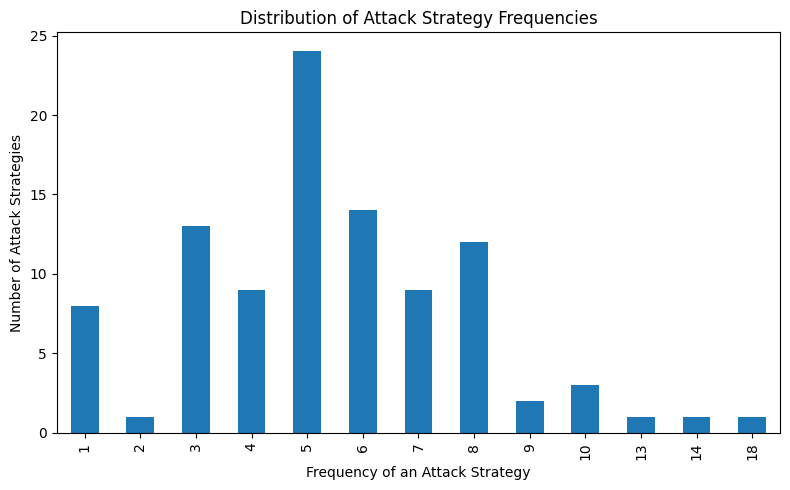


Frequency Statistics
------------------------------
count    98.000000
mean      5.520408
std       2.781491
min       1.000000
25%       4.000000
50%       5.000000
75%       7.000000
max      18.000000
Name: count, dtype: float64


In [37]:
attack_re = re.compile(r"Attack:\s*(.+)", re.IGNORECASE)
df["correct_action"] = df["assistant_response"].apply(lambda x: attack_re.search(str(x)).group(1).strip() if attack_re.search(str(x)) else None)

action_df = df.dropna(subset=["correct_action"]).copy()
total_samples = len(action_df)
unique_actions = action_df["correct_action"].nunique()

print("ATTACK STRATEGY STATISTICS")
print(f"Total Samples           : {total_samples}")
print(f"Unique Attack Strategies: {unique_actions}")

# Frequency of Every Attack Strategy
action_counts = action_df["correct_action"].value_counts()
print("\nTop 20 Attack Strategies\n")
display(action_counts.head(20))

# Long Tail Statistics
print("\nLong Tail Statistics")
print(f"Appear exactly once : {(action_counts == 1).sum()}")
print(f"Appear exactly twice: {(action_counts == 2).sum()}")
print(f"Appear <= 5 times   : {(action_counts <= 5).sum()}")
print(f"Appear > 10 times   : {(action_counts > 10).sum()}")

# Histogram of Attack Strategy Frequencies
plt.figure(figsize=(8, 5))
action_counts.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Frequency of an Attack Strategy")
plt.ylabel("Number of Attack Strategies")
plt.title("Distribution of Attack Strategy Frequencies")
plt.tight_layout()
plt.show()

# Summary Statistics
print("\nFrequency Statistics")
print("-" * 30)
print(action_counts.describe())

# Conversation Statistics

In [7]:
df["system_chars"]   =df["system_prompt"].str.len()
df["user_chars"]     =df["user_prompt"].str.len()
df["assistant_chars"]=df["assistant_response"].str.len()

stats=pd.DataFrame({
    "Field" : ["System Prompt","User Prompt","Assistant Response"],
    "Mean"  : [df["system_chars"].mean(),df["user_chars"].mean(),df["assistant_chars"].mean()],
    "Median": [df["system_chars"].median(),df["user_chars"].median(),df["assistant_chars"].median()],
    "Min"   : [df["system_chars"].min(),df["user_chars"].min(),df["assistant_chars"].min()],
    "Max"   : [df["system_chars"].max(),df["user_chars"].max(),df["assistant_chars"].max()],
    "Std"   : [df["system_chars"].std(),df["user_chars"].std(),df["assistant_chars"].std()]})

display(stats.round(2))

,Field,Mean,Median,Min,Max,Std
0,System Prompt,1264.00,1264.0,1264,1264,0.00
1,User Prompt,35339.49,33125.5,3600,95838,18012.67
2,Assistant Response,2127.12,2048.5,51,5095,983.37


# Character Length Distribution

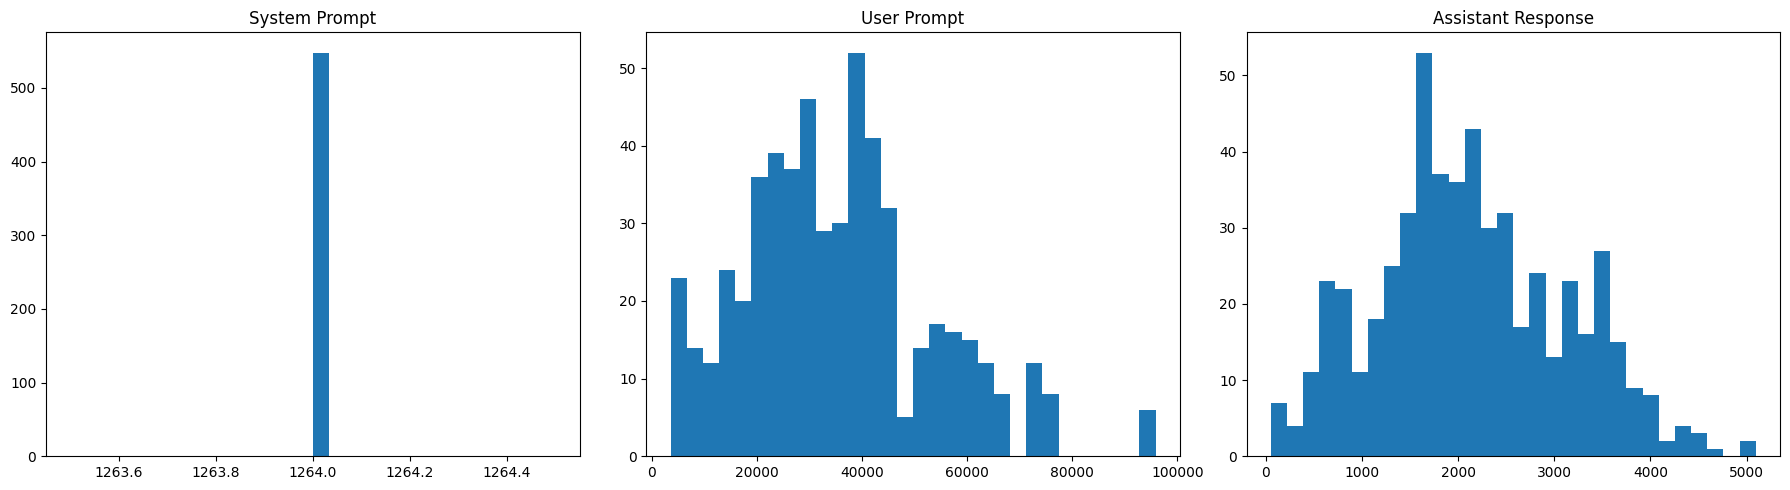

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

ax[0].hist(df["system_chars"], bins=30)
ax[0].set_title("System Prompt")
ax[1].hist(df["user_chars"], bins=30)
ax[1].set_title("User Prompt")
ax[2].hist(df["assistant_chars"], bins=30)
ax[2].set_title("Assistant Response")

plt.tight_layout()
plt.show()

# Prompt Token Statistics

In [14]:
MODELS={"Meta-Llama-3.1-8B-Instruct": "unsloth/Meta-Llama-3.1-8B-Instruct",
          "Qwen2.5-7B-Instruct": "unsloth/Qwen2.5-7B-Instruct",
          "Qwen3-8B": "unsloth/Qwen3-8B"}

COLUMN_PREFIX={"Meta-Llama-3.1-8B-Instruct": "llama",
                 "Qwen2.5-7B-Instruct": "qwen25",
                 "Qwen3-8B": "qwen3"}

results=[]
tokenizers={}

for model_name,model_path in MODELS.items():

    print(f"Loading Tokenizer: {model_name}")

    try:
        tokenizer = AutoTokenizer.from_pretrained(model_path,trust_remote_code=True)
        tokenizers[model_name] = tokenizer
        prompt_tokens = []

        for _,row in df.iterrows():

            prompt = (row["system_prompt"] + "\n" + row["user_prompt"])
            token_count = len(tokenizer(prompt,add_special_tokens=False)["input_ids"])
            prompt_tokens.append(token_count)

        prefix=COLUMN_PREFIX[model_name]
        df[f"{prefix}_prompt_tokens"]=prompt_tokens

        token_series = pd.Series(prompt_tokens)

        results.append({
            "Tokenizer": model_name,
            "Mean"    : round(token_series.mean(),2),
            "Median"  : round(token_series.median(),2),
            "Minimum" : int(token_series.min()),
            "Maximum" : int(token_series.max()),
            "Std Dev" : round(token_series.std(),2),
            "Variance": round(token_series.var(),2),
            "90%": round(token_series.quantile(0.90),2),
            "95%": round(token_series.quantile(0.95),2),
            "99%": round(token_series.quantile(0.99),2)})

        print("Success")

    except Exception as e:
        print(f"Failed to load {model_name}")
        print(e)

comparison = pd.DataFrame(results)

print("=" * 120)
print("PROMPT TOKENIZER COMPARISON")
print("=" * 120)

display(comparison)

Loading Tokenizer: Meta-Llama-3.1-8B-Instruct
Success
Loading Tokenizer: Qwen2.5-7B-Instruct
Success
Loading Tokenizer: Qwen3-8B
Success
PROMPT TOKENIZER COMPARISON


,Tokenizer,Mean,Median,Minimum,Maximum,Std Dev,Variance,90%,95%,99%
0,Meta-Llama-3.1-8B-Instruct,6687.70,6245.5,898,18765,3437.83,11818642.12,11840.5,12853.85,17427.76
1,Qwen2.5-7B-Instruct,6708.05,6254.5,904,18871,3449.06,11895988.99,11865.5,12881.85,17503.21
2,Qwen3-8B,6708.05,6254.5,904,18871,3449.06,11895988.99,11865.5,12881.85,17503.21


# Assistant Response Token Statistics Comparison

In [15]:
results = []

for model_name, tokenizer in tokenizers.items():

    print(f"Using Tokenizer: {model_name}")
    assistant_tokens = []

    for text in df["assistant_response"]:

        token_count = len(tokenizer(text,add_special_tokens=False)["input_ids"])
        assistant_tokens.append(token_count)

    prefix=COLUMN_PREFIX[model_name]
    df[f"{prefix}_assistant_tokens"]=assistant_tokens

    token_series = pd.Series(assistant_tokens)
    results.append({
        "Tokenizer": model_name,
        "Mean"    : round(token_series.mean(),2),
        "Median"  : round(token_series.median(),2),
        "Minimum" : int(token_series.min()),
        "Maximum" : int(token_series.max()),
        "Std Dev" : round(token_series.std(),2),
        "Variance": round(token_series.var(),2),
        "90%": round(token_series.quantile(0.90),2),
        "95%": round(token_series.quantile(0.95),2),
        "99%": round(token_series.quantile(0.99),2)})

comparison = pd.DataFrame(results)

print("=" * 120)
print("ASSISTANT TOKENIZER COMPARISON")
print("=" * 120)

display(comparison)

Using Tokenizer: Meta-Llama-3.1-8B-Instruct
Using Tokenizer: Qwen2.5-7B-Instruct
Using Tokenizer: Qwen3-8B
ASSISTANT TOKENIZER COMPARISON


,Tokenizer,Mean,Median,Minimum,Maximum,Std Dev,Variance,90%,95%,99%
0,Meta-Llama-3.1-8B-Instruct,367.00,329.0,8,1081,187.78,35259.55,643.9,716.30,830.89
1,Qwen2.5-7B-Instruct,368.81,331.0,8,1150,189.79,36018.50,644.6,729.25,833.42
2,Qwen3-8B,368.81,331.0,8,1150,189.79,36018.50,644.6,729.25,833.42


# Training Sequence Token Statistics Comparison

In [16]:
results = []

for model_name, tokenizer in tokenizers.items():

    print(f"Using Tokenizer: {model_name}")

    training_tokens = []

    for messages in df["messages"]:

        formatted_text=tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=False)
        token_count=len(tokenizer(formatted_text,add_special_tokens=False)["input_ids"])
        training_tokens.append(token_count)

    prefix=COLUMN_PREFIX[model_name]
    df[f"{prefix}_training_tokens"]=training_tokens

    token_series = pd.Series(training_tokens)

    results.append({
        "Tokenizer": model_name,
        "Mean"    : round(token_series.mean(),2),
        "Median"  : round(token_series.median(),2),
        "Minimum" : int(token_series.min()),
        "Maximum" : int(token_series.max()),
        "Std Dev" : round(token_series.std(),2),
        "Variance": round(token_series.var(),2),
        "90%": round(token_series.quantile(0.90),2),
        "95%": round(token_series.quantile(0.95),2),
        "99%": round(token_series.quantile(0.99),2)})

comparison = pd.DataFrame(results)

print("=" * 120)
print("TRAINING SEQUENCE TOKENIZER COMPARISON")
print("=" * 120)

display(comparison)

Using Tokenizer: Meta-Llama-3.1-8B-Instruct
Using Tokenizer: Qwen2.5-7B-Instruct
Using Tokenizer: Qwen3-8B
TRAINING SEQUENCE TOKENIZER COMPARISON


,Tokenizer,Mean,Median,Minimum,Maximum,Std Dev,Variance,90%,95%,99%
0,Meta-Llama-3.1-8B-Instruct,7090.70,6663.0,984,19252,3535.16,12497330.66,12373.8,13342.9,17972.23
1,Qwen2.5-7B-Instruct,7091.86,6663.0,969,19337,3547.11,12581961.55,12389.3,13355.3,18026.68
2,Qwen3-8B,7095.86,6667.0,973,19341,3547.11,12581961.55,12393.3,13359.3,18030.68


In [17]:
df.columns

Index(['scenario_id', 'example_id', 'messages', 'system_prompt', 'user_prompt',
       'assistant_response', 'system_chars', 'user_chars', 'assistant_chars',
       'llama_prompt_tokens', 'qwen25_prompt_tokens', 'qwen3_prompt_tokens',
       'llama_assistant_tokens', 'qwen25_assistant_tokens',
       'qwen3_assistant_tokens', 'llama_training_tokens',
       'qwen25_training_tokens', 'qwen3_training_tokens'],
      dtype='object')

# Token Length Distribution

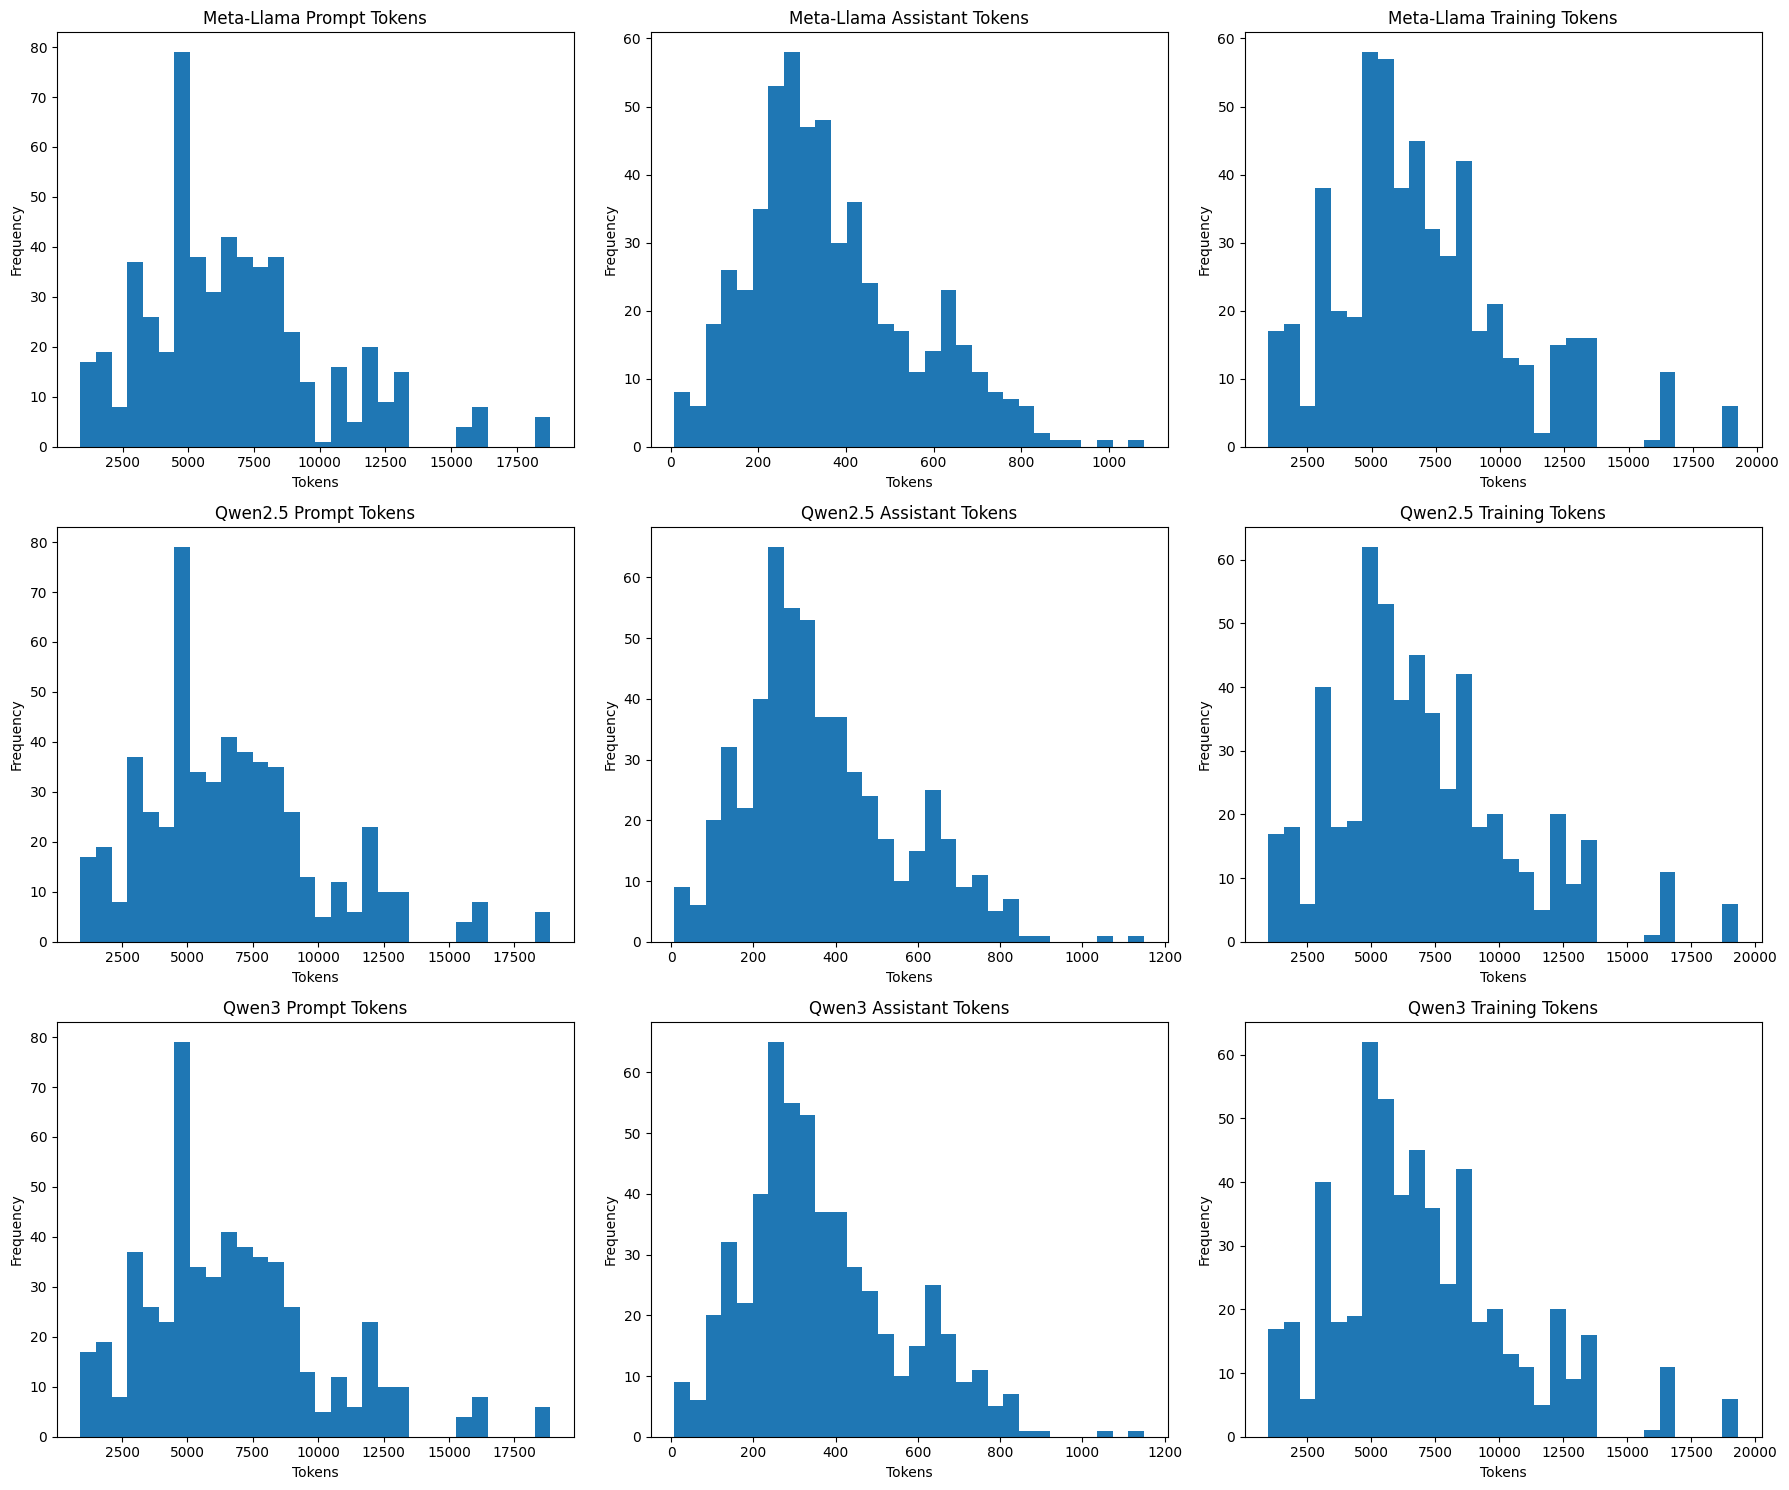

In [18]:
fig,ax=plt.subplots(3,3,figsize=(18,15))

# Meta-Llama

ax[0,0].hist(df["llama_prompt_tokens"], bins=30)
ax[0,0].set_title("Meta-Llama Prompt Tokens")
ax[0,0].set_xlabel("Tokens")
ax[0,0].set_ylabel("Frequency")

ax[0,1].hist(df["llama_assistant_tokens"], bins=30)
ax[0,1].set_title("Meta-Llama Assistant Tokens")
ax[0,1].set_xlabel("Tokens")
ax[0,1].set_ylabel("Frequency")

ax[0,2].hist(df["llama_training_tokens"], bins=30)
ax[0,2].set_title("Meta-Llama Training Tokens")
ax[0,2].set_xlabel("Tokens")
ax[0,2].set_ylabel("Frequency")


# Qwen2.5

ax[1,0].hist(df["qwen25_prompt_tokens"], bins=30)
ax[1,0].set_title("Qwen2.5 Prompt Tokens")
ax[1,0].set_xlabel("Tokens")
ax[1,0].set_ylabel("Frequency")

ax[1,1].hist(df["qwen25_assistant_tokens"], bins=30)
ax[1,1].set_title("Qwen2.5 Assistant Tokens")
ax[1,1].set_xlabel("Tokens")
ax[1,1].set_ylabel("Frequency")

ax[1,2].hist(df["qwen25_training_tokens"], bins=30)
ax[1,2].set_title("Qwen2.5 Training Tokens")
ax[1,2].set_xlabel("Tokens")
ax[1,2].set_ylabel("Frequency")

# Qwen3
ax[2,0].hist(df["qwen3_prompt_tokens"], bins=30)
ax[2,0].set_title("Qwen3 Prompt Tokens")
ax[2,0].set_xlabel("Tokens")
ax[2,0].set_ylabel("Frequency")

ax[2,1].hist(df["qwen3_assistant_tokens"], bins=30)
ax[2,1].set_title("Qwen3 Assistant Tokens")
ax[2,1].set_xlabel("Tokens")
ax[2,1].set_ylabel("Frequency")

ax[2,2].hist(df["qwen3_training_tokens"], bins=30)
ax[2,2].set_title("Qwen3 Training Tokens")
ax[2,2].set_xlabel("Tokens")
ax[2,2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Token Length Boxplots

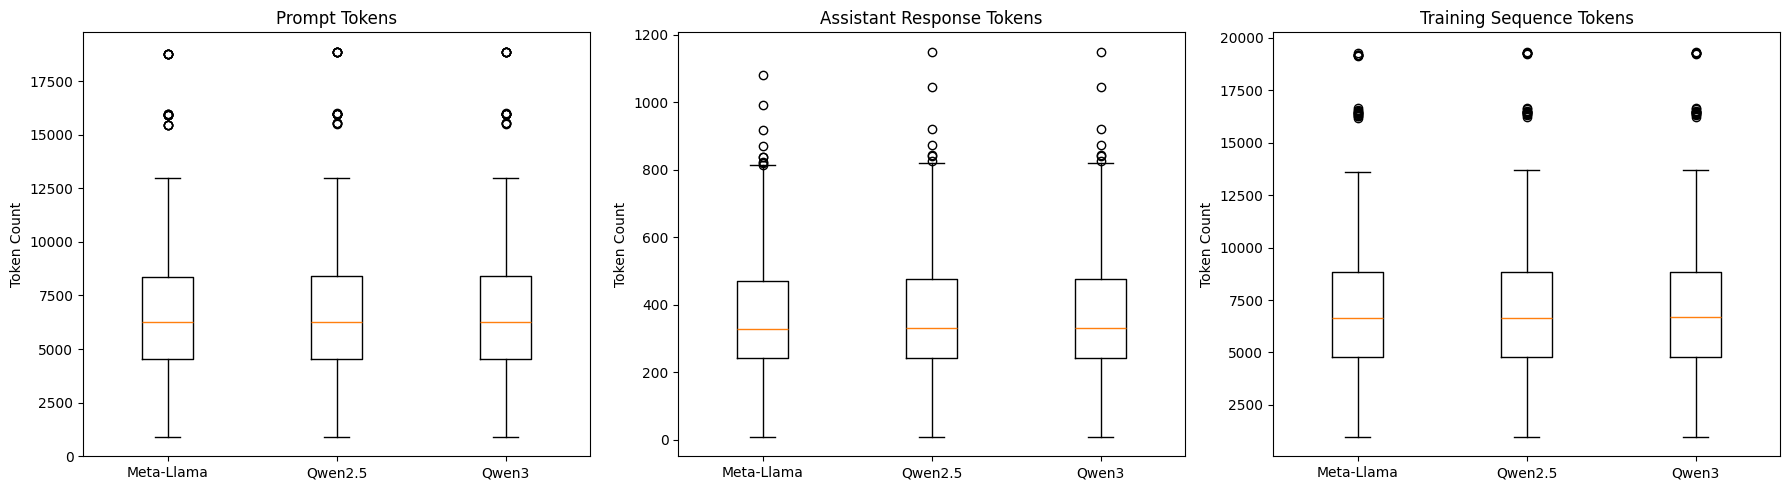

In [19]:
fig,ax=plt.subplots(1,3,figsize=(18,5))

# Prompt Tokens
ax[0].boxplot([df["llama_prompt_tokens"],
               df["qwen25_prompt_tokens"],
               df["qwen3_prompt_tokens"]],tick_labels=["Meta-Llama", "Qwen2.5", "Qwen3"])
ax[0].set_title("Prompt Tokens")
ax[0].set_ylabel("Token Count")

# Assistant Tokens
ax[1].boxplot([df["llama_assistant_tokens"],
               df["qwen25_assistant_tokens"],
               df["qwen3_assistant_tokens"]],tick_labels=["Meta-Llama", "Qwen2.5", "Qwen3"])
ax[1].set_title("Assistant Response Tokens")
ax[1].set_ylabel("Token Count")

# Training Sequence Tokens
ax[2].boxplot([df["llama_training_tokens"],
               df["qwen25_training_tokens"],
               df["qwen3_training_tokens"]],tick_labels=["Meta-Llama", "Qwen2.5", "Qwen3"])
ax[2].set_title("Training Sequence Tokens")
ax[2].set_ylabel("Token Count")

plt.tight_layout()
plt.show()

# Outliers using IQR

In [20]:
token_columns = {"Meta-Llama": "llama_training_tokens",
                 "Qwen2.5": "qwen25_training_tokens",
                 "Qwen3": "qwen3_training_tokens"}

for model_name, column in token_columns.items():

    print(model_name)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    upper = Q3 + 1.5 * IQR
    outliers = df[df[column] > upper]

    print(f"Q1          : {Q1:.2f}")
    print(f"Q3          : {Q3:.2f}")
    print(f"IQR         : {IQR:.2f}")
    print(f"Upper Bound : {upper:.2f}")
    print(f"Outliers    : {len(outliers)}")

    display(outliers[["scenario_id",column]].sort_values(column, ascending=False))

Meta-Llama
Q1          : 4794.00
Q3          : 8826.50
IQR         : 4032.50
Upper Bound : 14875.25
Outliers    : 18


,scenario_id,llama_training_tokens
261,scenario_055,19252
260,scenario_055,19179
258,scenario_055,19178
259,scenario_055,19170
257,scenario_055,19168
256,scenario_055,19143
501,scenario_095,16652
508,scenario_095,16565
502,scenario_095,16487
504,scenario_095,16441


Qwen2.5
Q1          : 4775.50
Q3          : 8851.75
IQR         : 4076.25
Upper Bound : 14966.12
Outliers    : 18


,scenario_id,qwen25_training_tokens
261,scenario_055,19337
260,scenario_055,19264
258,scenario_055,19263
259,scenario_055,19255
257,scenario_055,19253
256,scenario_055,19228
501,scenario_095,16672
508,scenario_095,16609
502,scenario_095,16513
504,scenario_095,16479


Qwen3
Q1          : 4779.50
Q3          : 8855.75
IQR         : 4076.25
Upper Bound : 14970.12
Outliers    : 18


,scenario_id,qwen3_training_tokens
261,scenario_055,19341
260,scenario_055,19268
258,scenario_055,19267
259,scenario_055,19259
257,scenario_055,19257
256,scenario_055,19232
501,scenario_095,16676
508,scenario_095,16613
502,scenario_095,16517
504,scenario_095,16483


# Context Window Coverage

In [21]:
context_windows=[1024, 2048, 4096, 6144, 8192, 12288]
training_columns={"Meta-Llama": "llama_training_tokens",
                    "Qwen2.5": "qwen25_training_tokens",
                    "Qwen3": "qwen3_training_tokens"}

coverage=[]

for model_name, column in training_columns.items():
    for window in context_windows:
        covered = (df[column] <= window).sum()
        coverage.append({
            "Tokenizer"      : model_name,
            "Context Window" : window,
            "Samples Covered": covered,
            "Coverage (%)"   : round(covered / len(df) * 100,2)})

coverage = pd.DataFrame(coverage)

display(coverage)

,Tokenizer,Context Window,Samples Covered,Coverage (%)
0,Meta-Llama,1024,4,0.73
1,Meta-Llama,2048,26,4.74
2,Meta-Llama,4096,102,18.61
3,Meta-Llama,6144,238,43.43
4,Meta-Llama,8192,370,67.52
5,Meta-Llama,12288,492,89.78
6,Qwen2.5,1024,4,0.73
7,Qwen2.5,2048,25,4.56
8,Qwen2.5,4096,102,18.61
9,Qwen2.5,6144,238,43.43


# Cumulative Distribution Function

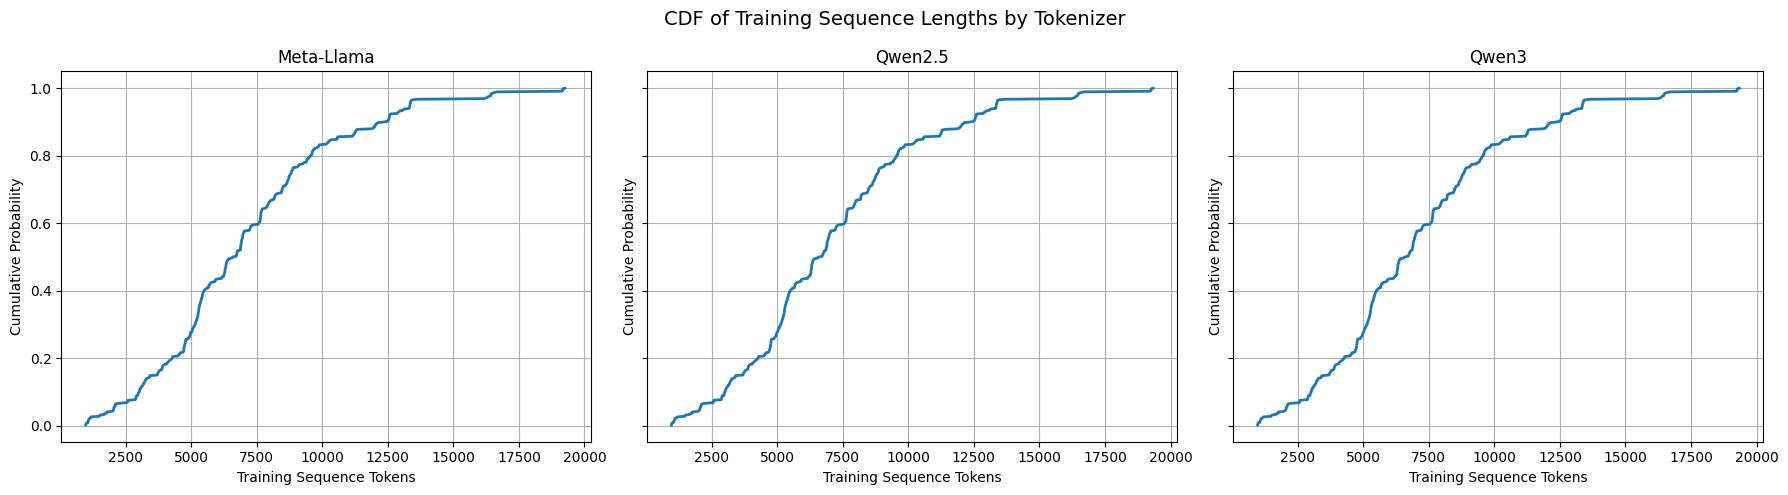

In [23]:
fig, ax=plt.subplots(1,3,figsize=(18,5),sharex=True,sharey=True)

token_columns = {"Meta-Llama": "llama_training_tokens",
                 "Qwen2.5": "qwen25_training_tokens",
                 "Qwen3": "qwen3_training_tokens"}

for axis, (model_name, column) in zip(ax, token_columns.items()):

    sorted_tokens=np.sort(df[column])
    cdf=np.arange(1, len(sorted_tokens) + 1) / len(sorted_tokens)

    axis.plot(sorted_tokens, cdf, linewidth=2)
    axis.set_title(model_name)
    axis.set_xlabel("Training Sequence Tokens")
    axis.set_ylabel("Cumulative Probability")
    axis.grid(True)

plt.suptitle("CDF of Training Sequence Lengths by Tokenizer", fontsize=14)
plt.tight_layout()
plt.show()

# Largest Training Samples

In [24]:
largest = (df.nlargest(40, "llama_training_tokens")[[
            "scenario_id",
            "llama_training_tokens",
            "qwen25_training_tokens",
            "qwen3_training_tokens",
            "llama_prompt_tokens",
            "llama_assistant_tokens"
        ]])

display(largest)

,scenario_id,llama_training_tokens,qwen25_training_tokens,qwen3_training_tokens,llama_prompt_tokens,llama_assistant_tokens
261,scenario_055,19252,19337,19341,18765,451
260,scenario_055,19179,19264,19268,18750,393
258,scenario_055,19178,19263,19267,18740,402
259,scenario_055,19170,19255,19259,18757,377
257,scenario_055,19168,19253,19257,18754,378
256,scenario_055,19143,19228,19232,18741,366
501,scenario_095,16652,16672,16676,15948,668
508,scenario_095,16565,16609,16613,15911,618
502,scenario_095,16487,16513,16517,15940,511
504,scenario_095,16441,16479,16483,15941,464


# Prompt vs Assistant Correlation

Meta-Llama Pearson Correlation : 0.4984
Qwen2.5 Pearson Correlation : 0.4965
Qwen3 Pearson Correlation : 0.4965


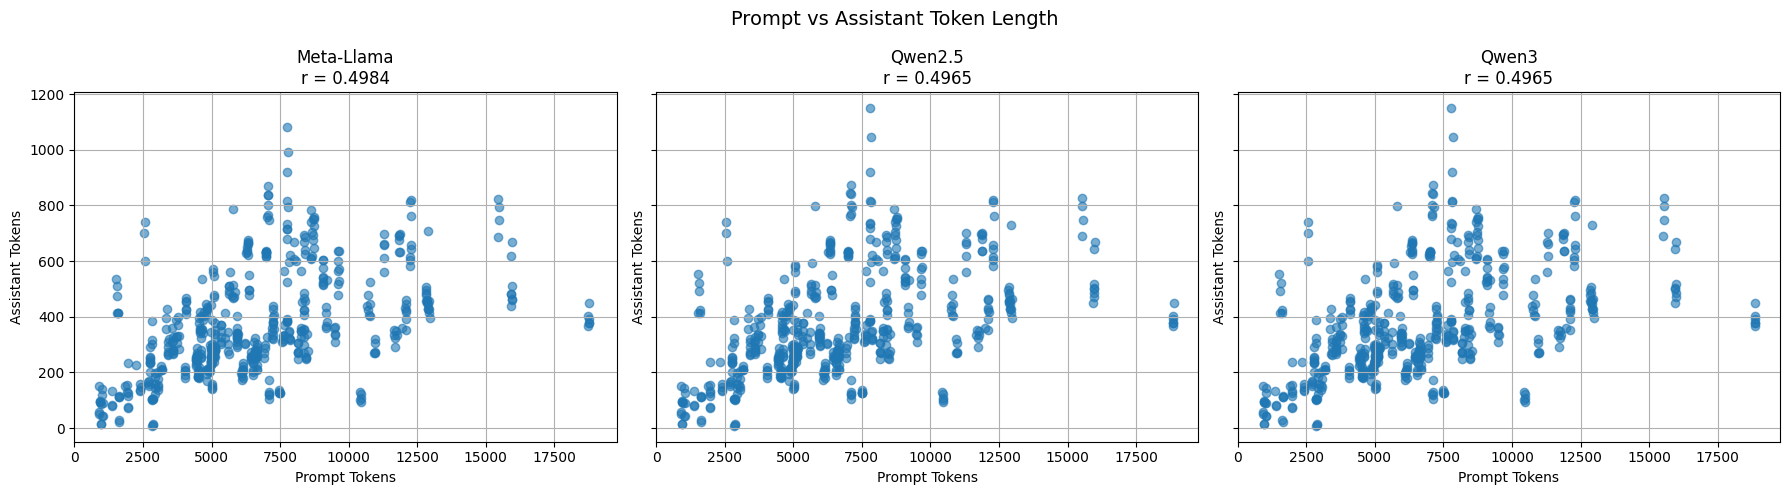

In [25]:
fig, ax=plt.subplots(1,3,figsize=(18, 5),sharex=True,sharey=True)

token_columns={"Meta-Llama": ("llama_prompt_tokens", "llama_assistant_tokens"),
                 "Qwen2.5": ("qwen25_prompt_tokens", "qwen25_assistant_tokens"),
                 "Qwen3": ("qwen3_prompt_tokens", "qwen3_assistant_tokens")}

for axis,(model_name, (prompt_col, assistant_col)) in zip(ax, token_columns.items()):

    corr=df[prompt_col].corr(df[assistant_col])
    print(f"{model_name} Pearson Correlation : {corr:.4f}")

    axis.scatter(df[prompt_col],df[assistant_col],alpha=0.6)
    axis.set_title(f"{model_name}\nr = {corr:.4f}")
    axis.set_xlabel("Prompt Tokens")
    axis.set_ylabel("Assistant Tokens")
    axis.grid(True)

plt.suptitle("Prompt vs Assistant Token Length", fontsize=14)
plt.tight_layout()
plt.show()

# Response-to-Prompt Ratio

Meta-Llama
count    548.000
mean       0.063
std        0.039
min        0.003
25%        0.040
50%        0.055
75%        0.078
max        0.356
dtype: float64
Qwen2.5
count    548.000
mean       0.063
std        0.040
min        0.003
25%        0.040
50%        0.055
75%        0.078
max        0.365
dtype: float64
Qwen3
count    548.000
mean       0.063
std        0.040
min        0.003
25%        0.040
50%        0.055
75%        0.078
max        0.365
dtype: float64


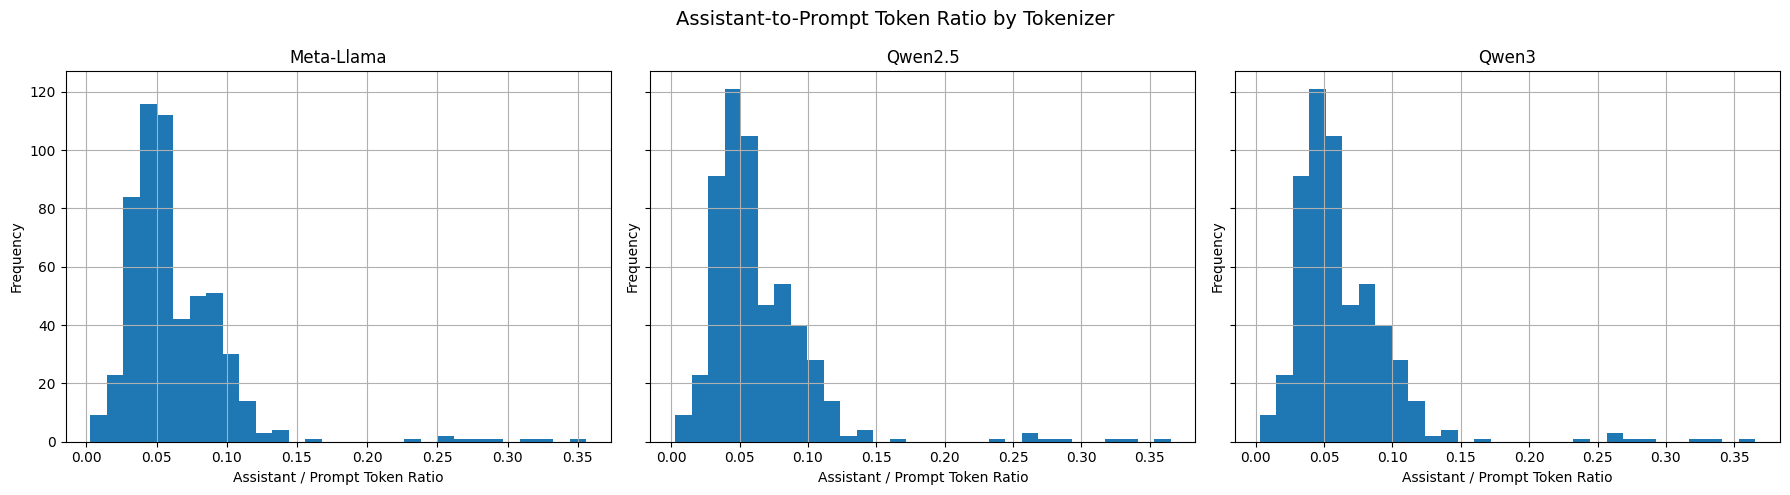

In [26]:
ratio_columns = {"Meta-Llama": ("llama_prompt_tokens", "llama_assistant_tokens"),
                 "Qwen2.5": ("qwen25_prompt_tokens", "qwen25_assistant_tokens"),
                 "Qwen3": ("qwen3_prompt_tokens", "qwen3_assistant_tokens")}

fig,ax=plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for axis,(model_name, (prompt_col, assistant_col)) in zip(ax, ratio_columns.items()):
    ratio = df[assistant_col] / df[prompt_col]
    print(model_name)
    print(ratio.describe().round(3))
    axis.hist(ratio, bins=30)
    axis.set_title(model_name)
    axis.set_xlabel("Assistant / Prompt Token Ratio")
    axis.set_ylabel("Frequency")
    axis.grid(True)

plt.suptitle("Assistant-to-Prompt Token Ratio by Tokenizer", fontsize=14)
plt.tight_layout()
plt.show()

df["llama_response_prompt_ratio"] = (df["llama_assistant_tokens"]/df["llama_prompt_tokens"])

df["qwen25_response_prompt_ratio"] = (df["qwen25_assistant_tokens"]/df["qwen25_prompt_tokens"])

df["qwen3_response_prompt_ratio"] = (df["qwen3_assistant_tokens"]/df["qwen3_prompt_tokens"])

Meta-Llama
count    548.00
mean       5.89
std        0.61
min        4.43
25%        5.42
50%        5.84
75%        6.37
max        7.42
dtype: float64
Qwen2.5
count    548.00
mean       5.87
std        0.62
min        4.23
25%        5.41
50%        5.80
75%        6.35
max        7.42
dtype: float64
Qwen3
count    548.00
mean       5.87
std        0.62
min        4.23
25%        5.41
50%        5.80
75%        6.35
max        7.42
dtype: float64


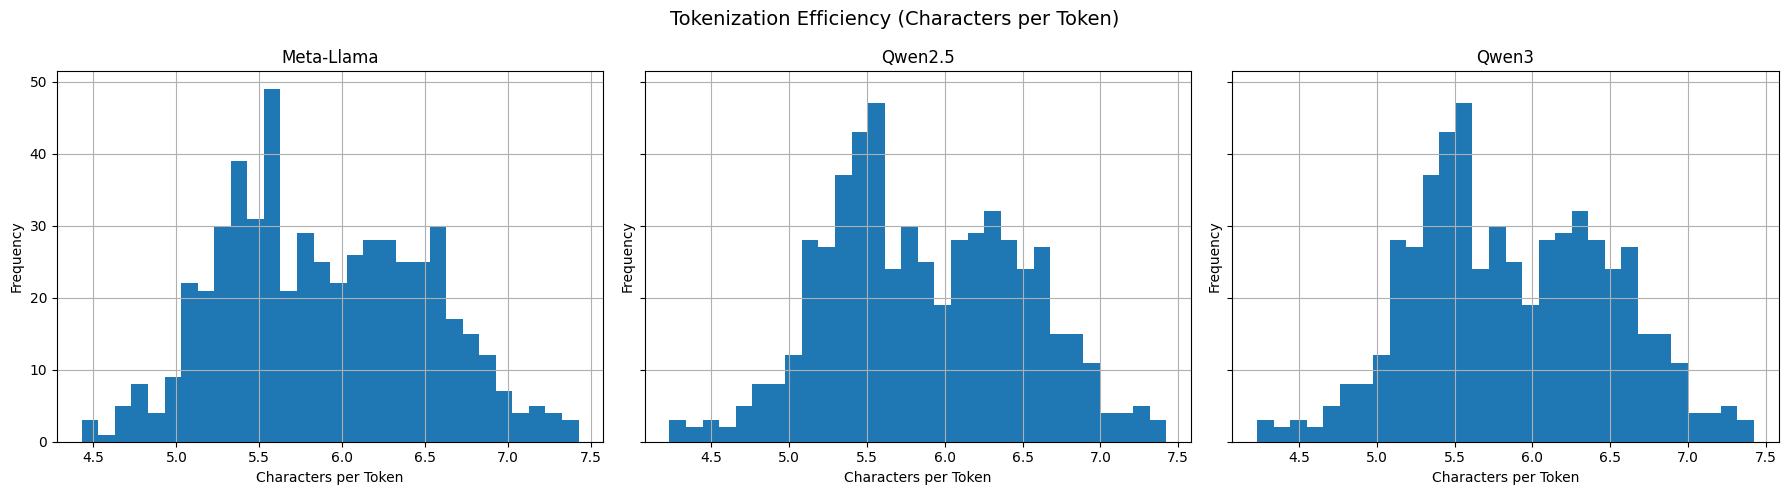

In [27]:
token_columns = {"Meta-Llama": "llama_assistant_tokens",
                 "Qwen2.5": "qwen25_assistant_tokens",
                 "Qwen3": "qwen3_assistant_tokens"}

fig,ax=plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for axis,(model_name, assistant_col) in zip(ax, token_columns.items()):

    chars_per_token = df["assistant_chars"] / df[assistant_col]
    print(model_name)
    print(chars_per_token.describe().round(2))

    axis.hist(chars_per_token, bins=30)
    axis.set_title(model_name)
    axis.set_xlabel("Characters per Token")
    axis.set_ylabel("Frequency")
    axis.grid(True)

plt.suptitle("Tokenization Efficiency (Characters per Token)", fontsize=14)
plt.tight_layout()
plt.show()

df["llama_chars_per_token"] = (df["assistant_chars"]/df["llama_assistant_tokens"])

df["qwen25_chars_per_token"] = (df["assistant_chars"]/df["qwen25_assistant_tokens"])

df["qwen3_chars_per_token"] = (df["assistant_chars"]/df["qwen3_assistant_tokens"])

# Assistant response format compliance

In [29]:
label_re = re.compile(r'^Attack:\s*(.+?)\n\nReasoning:\s*(.*)$',re.DOTALL)

def check_format(row):
    m=label_re.match(row["assistant_response"].strip())
    return m is not None

df["format_compliant"]=df.apply(check_format,axis=1)

non_compliant=df[~df["format_compliant"]]
print(f"Format non-compliant: {len(non_compliant)} / {len(df)}")

display(non_compliant[["scenario_id", "example_id", "assistant_response"]].assign(preview=lambda d: d["assistant_response"].str.slice(0, 200))
        [["scenario_id", "example_id", "preview"]])

Format non-compliant: 15 / 548


,scenario_id,example_id,preview
30,scenario_010,R4,The upload workflow appears protected by FileV...
31,scenario_010,R5,"FileValidator.kt, MimeTypeValidator.kt, and Vi..."
35,scenario_011,R4,Customer records enter through customer_import...
36,scenario_011,R5,The logging system uses elastic_logger.py and ...
42,scenario_012,R6,Analytics-service contains service token gener...
43,scenario_012,R7,JWT validation appears to be implemented corre...
44,scenario_012,R8,The platform establishes trust using service i...
477,scenario_092,R1,Attack: Trust Anchor Context Collapse\n\nRoot ...
478,scenario_092,R2,Attack: Trust Anchor Context Collapse\n\nSecur...
479,scenario_092,R3,Attack: Trust Anchor Context Collapse\n\nState...


# Check for Leakage of Reserved Metadata Keys

In [30]:
reserved_keys=["valid_attack","valid_attacks","valid_defense","valid_defenses","optimal_attack","optimal_attacks","optimal_defense","optimal_defenses","metadata.json"]

def scan_leakage(messages):
    if messages is None:
        return []
    # Convert the entire conversation to a string
    # default=str prevents JSON serialization errors
    full_text = json.dumps(messages, default=str)

    # Return all reserved keys found in the conversation
    return [key for key in reserved_keys if key in full_text]


df["leaked_keys"]=df["messages"].apply(scan_leakage)

# Keep only rows where at least one key was found
leaks = df[df["leaked_keys"].apply(len)>0]

print("RESERVED KEY LEAKAGE CHECK")
print(f"Rows with reserved-key leakage: {len(leaks)}/{len(df)}")

if len(leaks) > 0:
    display(leaks[["scenario_id","example_id","leaked_keys"]])
else:
    print("No reserved metadata leakage detected.")

RESERVED KEY LEAKAGE CHECK
Rows with reserved-key leakage: 0/548
No reserved metadata leakage detected.


In [31]:
reasoning_re=re.compile(r"Reasoning:\s*(.*)",re.DOTALL)

def extract_reasoning(text):

    if pd.isna(text):
        return ""

    match = reasoning_re.search(text)
    return match.group(1).strip() if match else ""

df["reasoning_body"]=df["assistant_response"].apply(extract_reasoning)

# Tokenizer
def tokenize_simple(text):
    return set(re.findall(r"[a-zA-Z_]{4,}", text.lower()))

# Sample data
sample_df = df.dropna(subset=["reasoning_body"])

if len(sample_df)>300:
    sample_df = sample_df.sample(300, random_state=42)

# Tokenize
token_sets = {idx: tokenize_simple(row["reasoning_body"])for idx, row in sample_df.iterrows()}

# Compare
near_dupes=[]
ids=list(token_sets.keys())

for i,j in combinations(ids, 2):

    row_i = sample_df.loc[i]
    row_j = sample_df.loc[j]

    if row_i["scenario_id"] == row_j["scenario_id"]:
        continue

    a=token_sets[i]
    b=token_sets[j]

    if not a or not b:
        continue

    jaccard=len(a & b) / len(a | b)

    if jaccard > 0.6:
        near_dupes.append((row_i["scenario_id"],row_j["scenario_id"],round(jaccard, 3)))

print(f"Cross-scenario near-duplicate reasoning pairs (Jaccard > 0.6): {len(near_dupes)}")

for pair in sorted(near_dupes, key=lambda x: -x[2])[:20]:
    print(pair)

Cross-scenario near-duplicate reasoning pairs (Jaccard > 0.6): 5
('scenario_036', 'scenario_035', 1.0)
('scenario_036', 'scenario_035', 1.0)
('scenario_074', 'scenario_075', 0.636)
('scenario_074', 'scenario_075', 0.627)
('scenario_075', 'scenario_074', 0.607)


# Prompt-framing diversity (R1 / R2 / R3)

,mean,median,min,max,count
example_id,,,,,
R1,32718.53,30724.0,3667,95720,100
R2,32612.52,30215.0,3600,95732,100
R3,32603.45,30316.5,3610,95706,100


R1: 100.0% of examples contain raw code in the user prompt
R2: 100.0% of examples contain raw code in the user prompt
R3: 100.0% of examples contain raw code in the user prompt


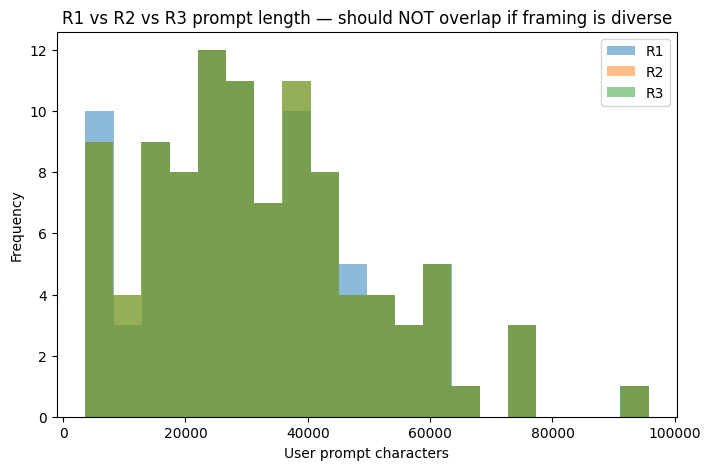

In [38]:
framing_stats = df.groupby("example_id")["user_chars"].agg(["mean", "median", "min", "max", "count"])
display(framing_stats.loc[["R1", "R2", "R3"]] if set(["R1","R2","R3"]).issubset(framing_stats.index) else framing_stats)

def has_code(text):
    return ("```" in text) or ("def " in text) or ("class " in text)

for ex_id in ["R1", "R2", "R3"]:
    subset = df[df["example_id"] == ex_id]
    if len(subset) == 0:
        continue
    code_frac = subset["user_prompt"].apply(has_code).mean()
    print(f"{ex_id}: {code_frac*100:.1f}% of examples contain raw code in the user prompt")

fig, ax = plt.subplots(figsize=(8, 5))
for ex_id in ["R1", "R2", "R3"]:
    subset = df[df["example_id"] == ex_id]
    if len(subset) == 0:
        continue
    ax.hist(subset["user_chars"], bins=20, alpha=0.5, label=ex_id)
ax.set_xlabel("User prompt characters")
ax.set_ylabel("Frequency")
ax.set_title("R1 vs R2 vs R3 prompt length — should NOT overlap if framing is diverse")
ax.legend()
plt.show()

# Distribution of Ground Truth Attack Strategies

Unique actions: 98 / 548 samples


correct_action
artifact_provenance_bypass                  18
tenant_context_confusion                    14
stale_approval_state_abuse                  13
training_dataset_provenance_bypass          10
stale_entitlement_cache_abuse               10
                                            ..
policy_resource_mismatch                     1
stale_runtime_session                        1
cross_identity_session_reuse                 1
authorization_graph_drift                    1
authorization_generation_replay_collapse     1
Name: count, Length: 98, dtype: int64

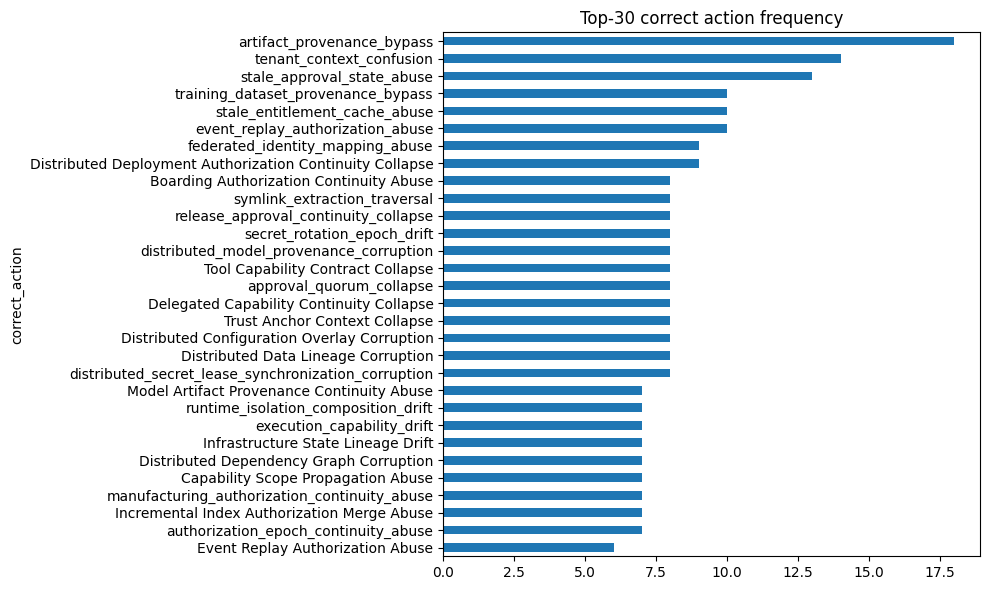

Actions with only 1 example: 8


In [39]:
action_re = re.compile(r'^(?:Attack):\s*(.+)$', re.MULTILINE)

df["correct_action"] = df["assistant_response"].apply(
    lambda t: (action_re.search(t).group(1).strip() if action_re.search(t) else None)
)

action_counts = df["correct_action"].value_counts()
print(f"Unique actions: {df['correct_action'].nunique()} / {len(df)} samples")
display(action_counts)

fig, ax = plt.subplots(figsize=(10,6))
action_counts.head(30).plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Top-30 correct action frequency")
plt.tight_layout(); plt.show()

# Long-tail check
print(f"Actions with only 1 example: {(action_counts==1).sum()}")

# Scenario-Level Analysis of Variants and Attack Strategy Diversity

SCENARIO DIVERSITY REPORT
Total scenarios               : 100
Total samples                 : 548
Average variants/scenario     : 5.48
Average attacks/scenario      : 1.10
Maximum variants in scenario  : 9
Maximum unique attacks        : 7


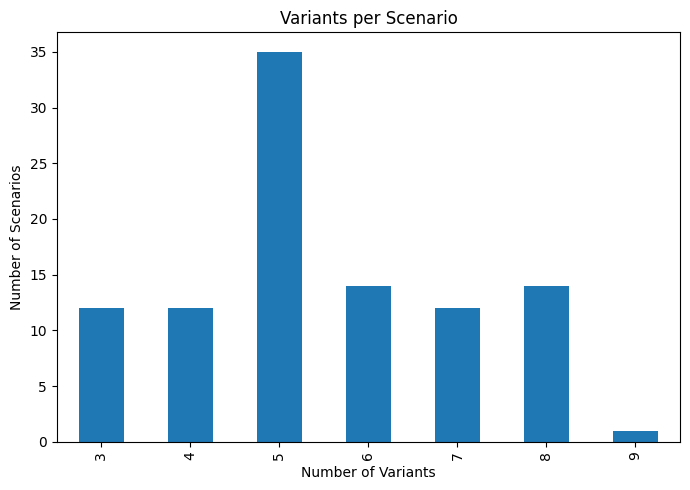

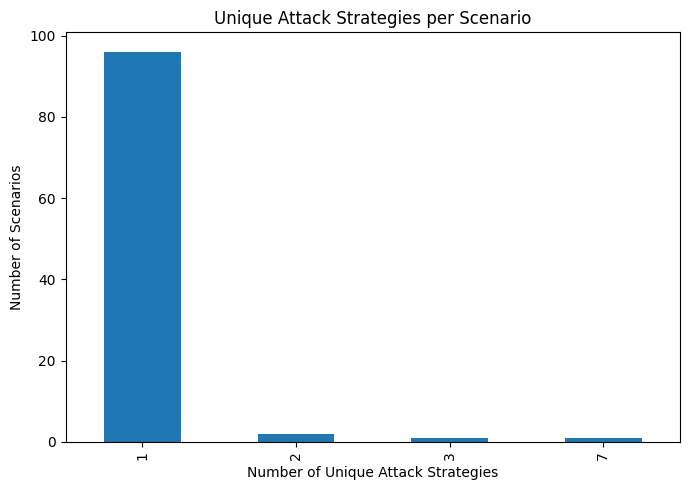


Top 10 Scenarios with Most Variants



,scenario_id,variants,unique_attacks
93,scenario_094,9,1
99,scenario_100,8,1
80,scenario_081,8,1
85,scenario_086,8,1
91,scenario_092,8,1
49,scenario_050,8,1
82,scenario_083,8,1
81,scenario_082,8,1
13,scenario_014,8,1
11,scenario_012,8,1



Top 10 Scenarios with Highest Attack Diversity



,scenario_id,variants,unique_attacks
94,scenario_095,8,7
89,scenario_090,7,3
76,scenario_077,7,2
77,scenario_078,7,2
0,scenario_001,3,1
63,scenario_064,4,1
71,scenario_072,5,1
70,scenario_071,6,1
69,scenario_070,5,1
68,scenario_069,6,1



Scenarios Having Multiple Attack Strategies



,scenario_id,example_id,correct_action
377,scenario_077,R1,safety_configuration_lineage_drift
378,scenario_077,R2,safety_configuration_lineage_drift
379,scenario_077,R3,safety_configuration_lineage_drift
380,scenario_077,R4,none
381,scenario_077,R5,none
382,scenario_077,R6,safety_configuration_lineage_drift
383,scenario_077,R7,safety_configuration_lineage_drift
384,scenario_078,R1,certificate_trust_lineage_drift
385,scenario_078,R2,certificate_trust_lineage_drift
386,scenario_078,R3,certificate_trust_lineage_drift


In [40]:
def scenario_diversity_report(df):

    # Per-scenario statistics
    scenario_stats = (df.groupby("scenario_id").agg(
              variants=("example_id", "count"),
              unique_attacks=("correct_action", "nunique")).reset_index())

    # Overall Summary
    print("SCENARIO DIVERSITY REPORT")
    print(f"Total scenarios               : {scenario_stats.shape[0]}")
    print(f"Total samples                 : {len(df)}")
    print(f"Average variants/scenario     : {scenario_stats['variants'].mean():.2f}")
    print(f"Average attacks/scenario      : {scenario_stats['unique_attacks'].mean():.2f}")
    print(f"Maximum variants in scenario  : {scenario_stats['variants'].max()}")
    print(f"Maximum unique attacks        : {scenario_stats['unique_attacks'].max()}")

    # Variant Distribution
    plt.figure(figsize=(7,5))
    scenario_stats["variants"].value_counts().sort_index().plot(kind="bar")
    plt.title("Variants per Scenario")
    plt.xlabel("Number of Variants")
    plt.ylabel("Number of Scenarios")
    plt.tight_layout()
    plt.show()

    # Attack Diversity Distribution
    plt.figure(figsize=(7,5))
    scenario_stats["unique_attacks"].value_counts().sort_index().plot(kind="bar")
    plt.title("Unique Attack Strategies per Scenario")
    plt.xlabel("Number of Unique Attack Strategies")
    plt.ylabel("Number of Scenarios")
    plt.tight_layout()
    plt.show()

    # Largest Scenarios
    print("\nTop 10 Scenarios with Most Variants\n")
    display(scenario_stats.sort_values("variants",ascending=False).head(10))

    # Most Diverse Scenarios
    print("\nTop 10 Scenarios with Highest Attack Diversity\n")
    display(scenario_stats.sort_values("unique_attacks",ascending=False).head(10))

    # Detailed Attack List
    print("\nScenarios Having Multiple Attack Strategies\n")
    diverse = (df.groupby("scenario_id")["correct_action"].nunique())
    diverse = diverse[diverse > 1].index

    display(df[df["scenario_id"].isin(diverse)] [["scenario_id", "example_id", "correct_action"]].sort_values(["scenario_id", "example_id"]))
    return scenario_stats

scenario_stats = scenario_diversity_report(df)

# Semantic Similarity Analysis for Detecting Near-Duplicate Reasoning Traces

In [41]:
model = SentenceTransformer("BAAI/bge-base-en-v1.5")

reasonings=df["reasoning_body"].fillna("").tolist()
embeddings = model.encode(reasonings,convert_to_numpy=True,normalize_embeddings=True,show_progress_bar=True)

SIM_THRESHOLD = 0.95
near_duplicate_pairs = []

for scenario_id, group in df.groupby("scenario_id"):

    idx = group.index.to_list()
    if len(idx) < 2:
        continue

    sim_matrix = cosine_similarity(embeddings[idx])
    for i in range(len(idx)):
        for j in range(i + 1, len(idx)):

            similarity = sim_matrix[i, j]
            if similarity >= SIM_THRESHOLD:
                near_duplicate_pairs.append({
                    "scenario_id": scenario_id,
                    "example_a": group.iloc[i]["example_id"],
                    "example_b": group.iloc[j]["example_id"],
                    "similarity": round(float(similarity),4)})

results = pd.DataFrame(near_duplicate_pairs)

print("=" * 60)
print("Semantic Similarity Analysis")
print("=" * 60)
print(f"Threshold                 : {SIM_THRESHOLD}")
print(f"Near-duplicate pairs      : {len(results)}")

if len(results):
    display(results.sort_values("similarity",ascending=False).reset_index(drop=True))

else:
    print("No near-duplicate reasoning found.")

total_samples=len(df)
total_scenarios=df["scenario_id"].nunique()
total_pairs=(df.groupby("scenario_id").size().apply(lambda x: comb(x, 2)).sum())
near_duplicates=len(results)

print("="*60)
print(f"Total Samples                 : {total_samples}")
print(f"Total Scenarios               : {total_scenarios}")
print(f"Total Pairwise Comparisons    : {total_pairs}")
print(f"Near Duplicate Pairs (>0.95)  : {near_duplicates}")
print(f"Duplicate Rate                : {near_duplicates/total_pairs:.2%}")
print("="*60)

Batches: 100%|██████████| 18/18 [00:22<00:00,  1.27s/it]

Semantic Similarity Analysis
Threshold                 : 0.95
Near-duplicate pairs      : 275


,scenario_id,example_a,example_b,similarity
0,scenario_010,R4,R5,1.0000
1,scenario_082,R1,R7,1.0000
2,scenario_081,R5,R8,1.0000
3,scenario_081,R6,R7,1.0000
4,scenario_081,R6,R8,1.0000
...,...,...,...,...
270,scenario_046,R4,R5,0.9507
271,scenario_045,R1,R2,0.9506
272,scenario_096,R1,R3,0.9506
273,scenario_055,R3,R4,0.9502


Total Samples                 : 548
Total Scenarios               : 100
Total Pairwise Comparisons    : 1348
Near Duplicate Pairs (>0.95)  : 275
Duplicate Rate                : 20.40%


# Analysis of Source File Extension Distribution Across Scenarios

FILE EXTENSION DISTRIBUTION
Total Samples              : 548
Total Files                : 6219
Unique Extension Types     : 67


.py      619
.go      539
.rs      537
.kt      507
.java    414
        ... 
.json      5
.chpl      5
.bal       5
.red       5
.yml       3
Name: count, Length: 67, dtype: int64

FILES WITHOUT EXTENSIONS


jenkins/Jenkinsfile    5
Name: count, dtype: int64

SCENARIO STATISTICS
Average Files / Scenario        : 11.04
Minimum Files / Scenario        : 4
Maximum Files / Scenario        : 20

Average Extension Types       : 5.29

Primary Extension Distribution


primary_extension
.py       13
.go       10
.cs       10
.kt        9
.java      9
.fs        8
.scala     6
.rs        6
.cpp       5
.swift     4
.ex        3
.js        3
.ml        2
.hs        2
.erl       2
.pas       1
.tcl       1
.zig       1
.rb        1
.ada       1
.cr        1
.idr       1
.gleam     1
Name: count, dtype: int64

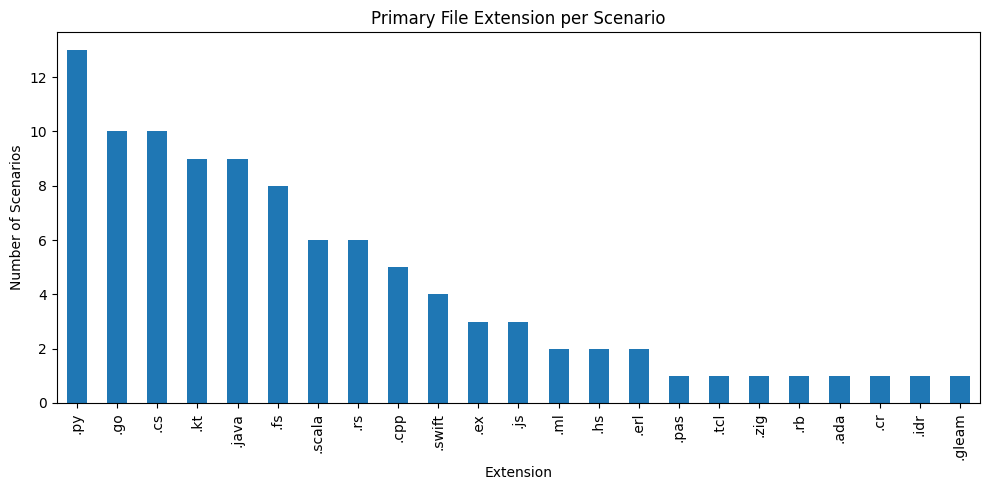

In [42]:
def extract_files(user_prompt):
    """
    Extract every filename appearing after '## FILE:'.
    """
    return re.findall(r"## FILE:\s*([^\n`]+)", user_prompt)

def get_extension(filename):
    """
    Return the complete extension.

    Examples:
        app.py            -> .py
        index.d.ts        -> .d.ts
        archive.tar.gz    -> .tar.gz
        Dockerfile        -> <no_extension>
        Makefile          -> <no_extension>
        .gitignore        -> <no_extension>
    """

    filename = filename.strip()
    suffixes = Path(filename).suffixes
    if suffixes:
        return "".join(suffixes).lower()
    return "<no_extension>"

df["files"] = df["user_prompt"].apply(extract_files)
df["extensions"] = df["files"].apply(lambda files: [get_extension(f) for f in files])

flat_extensions = [ext for extensions in df["extensions"] for ext in extensions]
extension_counts = pd.Series(flat_extensions).value_counts()

print("FILE EXTENSION DISTRIBUTION")
print(f"Total Samples              : {len(df)}")
print(f"Total Files                : {len(flat_extensions)}")
print(f"Unique Extension Types     : {extension_counts.shape[0]}")

display(extension_counts)

no_extension_files = []
for files in df["files"]:
    for f in files:
        if get_extension(f) == "<no_extension>":
            no_extension_files.append(f)

print("FILES WITHOUT EXTENSIONS")

if len(no_extension_files):
    display(pd.Series(no_extension_files).value_counts())
else:
    print("None")


scenario_df = (df.groupby("scenario_id").first().reset_index())
scenario_df["num_files"] = scenario_df["files"].apply(len)
scenario_df["num_extension_types"] = scenario_df["extensions"].apply(lambda x: len(set(x)))
scenario_df["primary_extension"] = scenario_df["extensions"].apply(lambda x: Counter(x).most_common(1)[0][0])

print("SCENARIO STATISTICS")
print(f"Average Files / Scenario        : {scenario_df['num_files'].mean():.2f}")
print(f"Minimum Files / Scenario        : {scenario_df['num_files'].min()}")
print(f"Maximum Files / Scenario        : {scenario_df['num_files'].max()}")
print(f"\nAverage Extension Types       : {scenario_df['num_extension_types'].mean():.2f}")

print("\nPrimary Extension Distribution")
display(scenario_df["primary_extension"].value_counts())

plt.figure(figsize=(10,5))
scenario_df["primary_extension"].value_counts().plot(kind="bar")
plt.title("Primary File Extension per Scenario")
plt.xlabel("Extension")
plt.ylabel("Number of Scenarios")
plt.tight_layout()
plt.show()

# Detection of Vulnerability Telegraphing Terms in Source Code

In [43]:
telegraph_terms = [r'\bvulnerab\w*', r'\binsecure\b', r'\bexploit\w*', r'\bTODO:?\s*fix\b',
                    r'\bBUG\b', r'\bunsafe\b', r'\bXXX\b', r'\bFIXME\b', r'\bbackdoor\b']
telegraph_re = re.compile("|".join(telegraph_terms), re.IGNORECASE)

def scan_code_telegraphing(user_text):
    code_blocks = re.findall(r'```(.*?)```', user_text, re.DOTALL)
    hits = []
    for block in code_blocks:
        found = telegraph_re.findall(block)
        if found: hits.extend(found)
    return hits

df["telegraph_hits"] = df["user_prompt"].apply(scan_code_telegraphing)
flagged = df[df["telegraph_hits"].apply(len) > 0]
print(f"Scenarios with telegraphing terms in code: {flagged['scenario_id'].nunique()}")
display(flagged[["scenario_id","example_id","telegraph_hits"]])

Scenarios with telegraphing terms in code: 15


,scenario_id,example_id,telegraph_hits
87,scenario_021,R1,[BUG]
88,scenario_021,R2,[BUG]
89,scenario_021,R3,[BUG]
90,scenario_021,R4,[BUG]
91,scenario_021,R5,[BUG]
...,...,...,...
367,scenario_075,R3,"[VULNERABILITY, exploitable, exploitable, VULN..."
368,scenario_075,R4,"[VULNERABILITY, exploitable, exploitable, VULN..."
369,scenario_075,R5,"[VULNERABILITY, exploitable, exploitable, VULN..."
370,scenario_075,R6,"[VULNERABILITY, exploitable, exploitable, VULN..."
